In [1]:
#Small Image Classification Using Convolutional Neural Network (CNN)

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

(50000, 32, 32, 3)

In [4]:
X_test.shape

(10000, 32, 32, 3)

In [5]:
y_train.shape

(50000, 1)

In [6]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [7]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [8]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

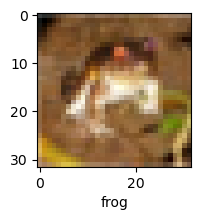

In [9]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])
plot_sample(X_train, y_train, 0)

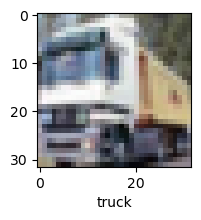

In [10]:
plot_sample(X_train, y_train, 1)

In [11]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [12]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')    
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 93s 58ms/step - accuracy: 0.3521 - loss: 1.8139
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.4257 - loss: 1.6247
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 57ms/step - accuracy: 0.4568 - loss: 1.5430
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 185s 85ms/step - accuracy: 0.4767 - loss: 1.4826
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 115s 73ms/step - accuracy: 0.4951 - loss: 1.4329


In [13]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.50      0.56      0.53      1000
           1       0.66      0.52      0.58      1000
           2       0.38      0.32      0.35      1000
           3       0.28      0.60      0.38      1000
           4       0.60      0.22      0.32      1000
           5       0.49      0.27      0.35      1000
           6       0.53      0.51      0.52      1000
           7       0.55      0.55      0.55      1000
           8       0.48      0.70      0.57      1000
           9       0.61      0.45      0.52      1000

    accuracy                           0.47     10000
   macro avg       0.51      0.47      0.47     10000
weighted avg       0.51      0.47      0.47     10000



In [14]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 52ms/step - accuracy: 0.4466 - loss: 1.5320
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.5887 - loss: 1.1684
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.6412 - loss: 1.0320
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6723 - loss: 0.9513
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 23ms/step - accuracy: 0.6925 - loss: 0.8880
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 33ms/step - accuracy: 0.7097 - loss: 0.8346
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 24ms/step - accuracy: 0.7265 - loss: 0.7898
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.7397 - loss: 0.7536
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.7513 - loss: 0.7195
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.7629 - loss: 0.6861


In [16]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6980 - loss: 0.9060


[0.9059703350067139, 0.6980000138282776]

In [17]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


array([[9.1889082e-03, 6.1391729e-06, 1.9220939e-03, 7.8263485e-01,
        7.6497288e-04, 1.8594500e-01, 1.7008886e-02, 8.0614780e-05,
        1.7499551e-03, 6.9864129e-04],
       [3.2781795e-02, 7.9597235e-02, 3.4533903e-05, 3.0606458e-05,
        1.4898938e-05, 4.1094546e-07, 8.1293831e-07, 9.9305942e-07,
        8.8713121e-01, 4.0755176e-04],
       [2.4603111e-01, 3.4928474e-01, 3.8959729e-03, 8.4951809e-03,
        3.5469520e-03, 9.9321874e-04, 8.9559198e-04, 8.3327424e-03,
        3.4164861e-01, 3.6875881e-02],
       [1.4097063e-01, 7.3292218e-02, 1.7763417e-02, 9.2110859e-04,
        1.8731080e-04, 3.2267832e-05, 1.3202684e-06, 6.6471781e-05,
        7.6556808e-01, 1.1972940e-03],
       [2.3056939e-05, 1.7241877e-05, 5.5672089e-03, 4.8374347e-02,
        3.6643669e-01, 1.3550150e-02, 5.6560099e-01, 8.3080613e-06,
        4.2168828e-04, 2.8131467e-07]], dtype=float32)

In [18]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(1), np.int64(8), np.int64(6)]

In [19]:
y_test[:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

TypeError: only integer scalar arrays can be converted to a scalar index

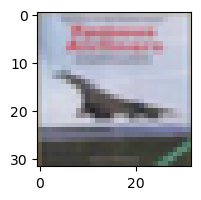

In [20]:
plot_sample(X_test, y_test,3)